In [1]:
# Phase 1 -Dataset verification
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DATA_DIR = r"C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset"


mat_files = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(".mat"):
            mat_files.append(os.path.join(root, file))

print("Number of MAT files:", len(mat_files))

for file in mat_files[:10]:
    print(file)

sample_file = mat_files[0]

data = sio.loadmat(sample_file)

print("File:", sample_file)
print("\nVariables:")

for key, value in data.items():
    if not key.startswith("__"):
        print(key, type(value), getattr(value, "shape", None))

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060
Number of MAT files: 3420
C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset\FORS-EMG Dataset\FORS-EMG Dataset\FORS-EMG\Subject1\pronation\Hand_Close-1.mat
C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset\FORS-EMG Dataset\FORS-EMG Dataset\FORS-EMG\Subject1\pronation\Hand_Close-2.mat
C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset\FORS-EMG Dataset\FORS-EMG Dataset\FORS-EMG\Subject1\pronation\Hand_Close-3.mat
C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset\FORS-EMG Dataset\FORS-EMG Dataset\FORS-EMG\Subject1\pronation\Hand_Close-4.mat
C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset\FORS-EMG Dataset\FORS-EMG Dataset\FORS-EMG\Subject1\pronation\Hand_Close-5.mat
C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset\FORS-EMG Dataset\FORS-EMG Dataset\FORS-EMG\Subject1\pronation\Hand_Open-1.mat
C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset\FORS-EMG Dataset

In [2]:
# Phase 2-Minimal metadata(File / Subject / Gesture)
import os
import re
import pandas as pd

records = []

for file_path in mat_files:
    relative_path = os.path.relpath(file_path, DATA_DIR)
    parts = relative_path.split(os.sep)

    subject = parts[-3]
    filename = parts[-1]

    name = os.path.splitext(filename)[0]
    match = re.match(r"(.+)-(\d+)$", name)

    gesture = match.group(1) if match else name

    records.append({
        "File": file_path,
        "Subject": subject,
        "Gesture": gesture
    })

metadata = pd.DataFrame(records)

print("Metadata shape:", metadata.shape)
print(metadata.head())
print("Subjects:", metadata["Subject"].nunique())
print("Gestures:", metadata["Gesture"].nunique())
print("Missing values:", metadata.isnull().sum().sum())

Metadata shape: (3420, 3)
                                                File   Subject     Gesture
0  C:\Users\Asus\Documents\Fors_EMG_Project\Fors_...  Subject1  Hand_Close
1  C:\Users\Asus\Documents\Fors_EMG_Project\Fors_...  Subject1  Hand_Close
2  C:\Users\Asus\Documents\Fors_EMG_Project\Fors_...  Subject1  Hand_Close
3  C:\Users\Asus\Documents\Fors_EMG_Project\Fors_...  Subject1  Hand_Close
4  C:\Users\Asus\Documents\Fors_EMG_Project\Fors_...  Subject1  Hand_Close
Subjects: 19
Gestures: 12
Missing values: 0


In [3]:
# Phase 3 -Subject-wise split
# Cell 1 — Define subjects
train_subjects = [
    "Subject1",
    "Subject2",
    "Subject3",
    "Subject4",
    "Subject5",
    "Subject6",
    "Subject7",
    "Subject8",
    "Subject9",
    "Subject10",
    "Subject11",
    "Subject12",
    "Subject13",
    "Subject14",
    "Subject15"
]

val_subjects = [
    "Subject16",
    "Subject17"
]

test_subjects = [
    "Subject18",
    "Subject19"
]

In [4]:
# Cell 2 — Create the three metadata sets
train_metadata = metadata[
    metadata["Subject"].isin(train_subjects)
].copy()

val_metadata = metadata[
    metadata["Subject"].isin(val_subjects)
].copy()

test_metadata = metadata[
    metadata["Subject"].isin(test_subjects)
].copy()

print("Training recordings:", len(train_metadata))
print("Validation recordings:", len(val_metadata))
print("Test recordings:", len(test_metadata))


Training recordings: 2700
Validation recordings: 360
Test recordings: 360


In [5]:
# Cell 3 — Verify subject separation

train_set = set(train_metadata["Subject"])
val_set = set(val_metadata["Subject"])
test_set = set(test_metadata["Subject"])

print("Train subjects:", sorted(train_set))
print("Validation subjects:", sorted(val_set))
print("Test subjects:", sorted(test_set))

print("\nTrain ∩ Validation:", train_set & val_set)
print("Train ∩ Test:", train_set & test_set)
print("Validation ∩ Test:", val_set & test_set)

Train subjects: ['Subject1', 'Subject10', 'Subject11', 'Subject12', 'Subject13', 'Subject14', 'Subject15', 'Subject2', 'Subject3', 'Subject4', 'Subject5', 'Subject6', 'Subject7', 'Subject8', 'Subject9']
Validation subjects: ['Subject16', 'Subject17']
Test subjects: ['Subject18', 'Subject19']

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [6]:
# Cell 4 — Automatic leakage check
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)

assert len(train_metadata) == 2700
assert len(val_metadata) == 360
assert len(test_metadata) == 360

print("Subject-wise split: PASSED")

Subject-wise split: PASSED


In [7]:
# Phase 4 — Windowing
# Cell 1 — Window parameters
FS = 985

WINDOW_SIZE = 492
STRIDE = 246

window_duration = WINDOW_SIZE / FS
stride_duration = STRIDE / FS
overlap = 1 - (STRIDE / WINDOW_SIZE)

print("Sampling Frequency:", FS, "Hz")
print("Window Size:", WINDOW_SIZE, "samples")
print("Window Duration:", round(window_duration, 4), "seconds")
print("Stride:", STRIDE, "samples")
print("Stride Duration:", round(stride_duration, 4), "seconds")
print("Overlap:", round(overlap * 100, 2), "%")

Sampling Frequency: 985 Hz
Window Size: 492 samples
Window Duration: 0.4995 seconds
Stride: 246 samples
Stride Duration: 0.2497 seconds
Overlap: 50.0 %


In [8]:
# Cell 2 — Windowing function
import numpy as np

def make_windows(signal, window_size=WINDOW_SIZE, stride=STRIDE):
    channels, total_samples = signal.shape

    windows = []

    for start in range(
        0,
        total_samples - window_size + 1,
        stride
    ):
        end = start + window_size
        windows.append(signal[:, start:end])

    return np.array(windows)


# Cell 3 — Test it on one recording
import scipy.io as sio

sample_file = train_metadata.iloc[0]["File"]

data = sio.loadmat(sample_file)
signal = data["value"]

windows = make_windows(signal)

print("Original signal shape:", signal.shape)
print("Windowed data shape:", windows.shape)
print("Number of windows:", windows.shape[0])
print("Channels per window:", windows.shape[1])
print("Samples per window:", windows.shape[2])


Original signal shape: (8, 8000)
Windowed data shape: (31, 8, 492)
Number of windows: 31
Channels per window: 8
Samples per window: 492


In [9]:
## 31 windows per recording
## 8 EMG channels per window
## 492 samples per channel
## 50% overlap
## ~0.5 seconds per window


In [10]:
# phase 5-Full Feature Extraction

# Cell 1 — Feature function
import numpy as np
from scipy.stats import skew, kurtosis

def extract_channel_features(channel):
    features = {}

    features["Mean"] = np.mean(channel)
    features["Median"] = np.median(channel)
    features["Std"] = np.std(channel)
    features["Min"] = np.min(channel)
    features["Max"] = np.max(channel)

    features["RMS"] = np.sqrt(np.mean(channel ** 2))
    features["PeakToPeak"] = np.ptp(channel)

    features["Q1"] = np.percentile(channel, 25)
    features["Q3"] = np.percentile(channel, 75)

    features["Skewness"] = skew(channel)
    features["Kurtosis"] = kurtosis(channel)

    features["WaveformLength"] = np.sum(
        np.abs(np.diff(channel))
    )

    features["ZeroCrossings"] = np.sum(
        np.diff(np.signbit(channel))
    )

    return features

In [11]:
test_window = windows[0]

test_features = {}

for ch in range(test_window.shape[0]):
    channel_features = extract_channel_features(
        test_window[ch]
    )

    for feature_name, value in channel_features.items():
        test_features[
            f"Ch{ch+1}_{feature_name}"
        ] = value

test_feature_vector = pd.Series(test_features)

print("Window shape:", test_window.shape)
print("Number of features:", len(test_feature_vector))

Window shape: (8, 492)
Number of features: 104


In [12]:
#One recording
#(8, 8000)
#   ↓
#31 windows
#(31, 8, 492)
#    ↓
#13 features × 8 channels
#    ↓
#31 × 104
#Now we need to finish Phase 5 by extracting the 104 features from all recordings.

In [13]:
def extract_window_features(window):
    features = []

    for ch in range(window.shape[0]):
        channel_features = extract_channel_features(window[ch])
        features.extend(channel_features.values())

    return np.array(features, dtype=np.float32)

def process_split(metadata):
    all_features = []
    all_labels = []
    all_subjects = []

    for _, row in metadata.iterrows():
        data = sio.loadmat(row["File"])
        signal = data["value"]

        windows = make_windows(signal)

        for window in windows:
            features = extract_window_features(window)

            all_features.append(features)
            all_labels.append(row["Gesture"])
            all_subjects.append(row["Subject"])

    X = np.array(all_features, dtype=np.float32)
    y = np.array(all_labels)
    subjects = np.array(all_subjects)

    return X, y, subjects

X_train, y_train, subjects_train = process_split(train_metadata)

print("Training feature shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Training subjects shape:", subjects_train.shape)

Training feature shape: (83700, 104)
Training labels shape: (83700,)
Training subjects shape: (83700,)


In [14]:
X_val, y_val, subjects_val = process_split(val_metadata)

print("Validation feature shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)
print("Validation subjects shape:", subjects_val.shape)


Validation feature shape: (11160, 104)
Validation labels shape: (11160,)
Validation subjects shape: (11160,)


In [15]:
X_test, y_test, subjects_test = process_split(test_metadata)

print("Test feature shape:", X_test.shape)
print("Test labels shape:", y_test.shape)
print("Test subjects shape:", subjects_test.shape)

Test feature shape: (11160, 104)
Test labels shape: (11160,)
Test subjects shape: (11160,)


In [16]:
print("========================================")
print("PHASE 5 FEATURE EXTRACTION")
print("========================================")

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print()
print("Number of features:", X_train.shape[1])
print("Number of training windows:", len(X_train))
print("Number of validation windows:", len(X_val))
print("Number of test windows:", len(X_test))

PHASE 5 FEATURE EXTRACTION
X_train: (83700, 104)
X_val  : (11160, 104)
X_test : (11160, 104)

Number of features: 104
Number of training windows: 83700
Number of validation windows: 11160
Number of test windows: 11160


In [18]:
#Phase 6 — Train-only normalization
#Create and fit scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)



#Verify normalization
print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

#Leakage check
print("Scaler fitted on training data only: YES")
print("Training mean:", np.mean(X_train_scaled))
print("Training std:", np.std(X_train_scaled))

Train shape: (83700, 104)
Validation shape: (11160, 104)
Test shape: (11160, 104)
Scaler fitted on training data only: YES
Training mean: 0.0
Training std: 1.0


In [21]:

#Phase 7 — PyTorch Dataset
#Now we finally start using PyTorch for the actual ML pipeline. following

#1.Convert the normalized NumPy arrays to PyTorch tensors.
#2.Convert gesture names into integer class labels.
#3.Create a PyTorch Dataset.

#Cell 1- Encode the gesture labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Number of classes:", len(label_encoder.classes_))
# Cell 2-Convert to PyTorch tensors
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

#Cell 3- Create the Dataset
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['Hand_Close' 'Hand_Open' 'Index' 'Index_Little' 'Peace'
 'Radial_Deviation' 'Right_Angle' 'Thumb_Little' 'Thumb_UP'
 'Ulner_Deviation' 'Wrist_Extension' 'Wrist_Flexion']
Number of classes: 12
X_train: torch.Size([83700, 104])
y_train: torch.Size([83700])
Training samples: 83700
Validation samples: 11160
Test samples: 11160


In [22]:
# Phase 8 — PyTorch DataLoader
# Create DataLoaders
from torch.utils.data import DataLoader

BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
#Check one batch
X_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", X_batch.shape)
print("Label batch shape:", y_batch.shape)
print("Input data type:", X_batch.dtype)
print("Label data type:", y_batch.dtype)

#Check the number of batches
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Input batch shape: torch.Size([256, 104])
Label batch shape: torch.Size([256])
Input data type: torch.float32
Label data type: torch.int64
Training batches: 327
Validation batches: 44
Test batches: 44


In [ ]:
####Pipeline is now fully prepared for PyTorch training

In [27]:
#Phase 9 — Baseline
#Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
#Define the MLP    
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)
#Create the model
INPUT_SIZE = X_train_tensor.shape[1]
NUM_CLASSES = len(label_encoder.classes_)

model = MLP(
    input_size=INPUT_SIZE,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

#Check the model with one batch
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

output = model(X_batch)

print("Input shape:", X_batch.shape)
print("Output shape:", output.shape)

Device: cuda
GPU: NVIDIA GeForce RTX 3060
MLP(
  (network): Sequential(
    (0): Linear(in_features=104, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=12, bias=True)
  )
)
Input shape: torch.Size([256, 104])
Output shape: torch.Size([256, 12])


In [84]:
#Phase 11A — Logistic Regression

#Cell 1
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train_encoded
)
#Cell 2
y_val_pred_lr = logistic_model.predict(X_val_scaled)

lr_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_lr
)

lr_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_lr,
    average="macro"
)

print("Logistic Regression")
print("Validation Accuracy:", round(lr_val_accuracy, 4))
print("Validation Macro F1 :", round(lr_val_f1, 4))
baseline_results = []

baseline_results.append({
    "Model": "Logistic Regression",
    "Validation Accuracy": lr_val_accuracy,
    "Validation Macro F1": lr_val_f1
})

print(baseline_results)

Logistic Regression
Validation Accuracy: 0.5006
Validation Macro F1 : 0.5097
[{'Model': 'Logistic Regression', 'Validation Accuracy': 0.5006272401433691, 'Validation Macro F1': 0.5096541292845856}]


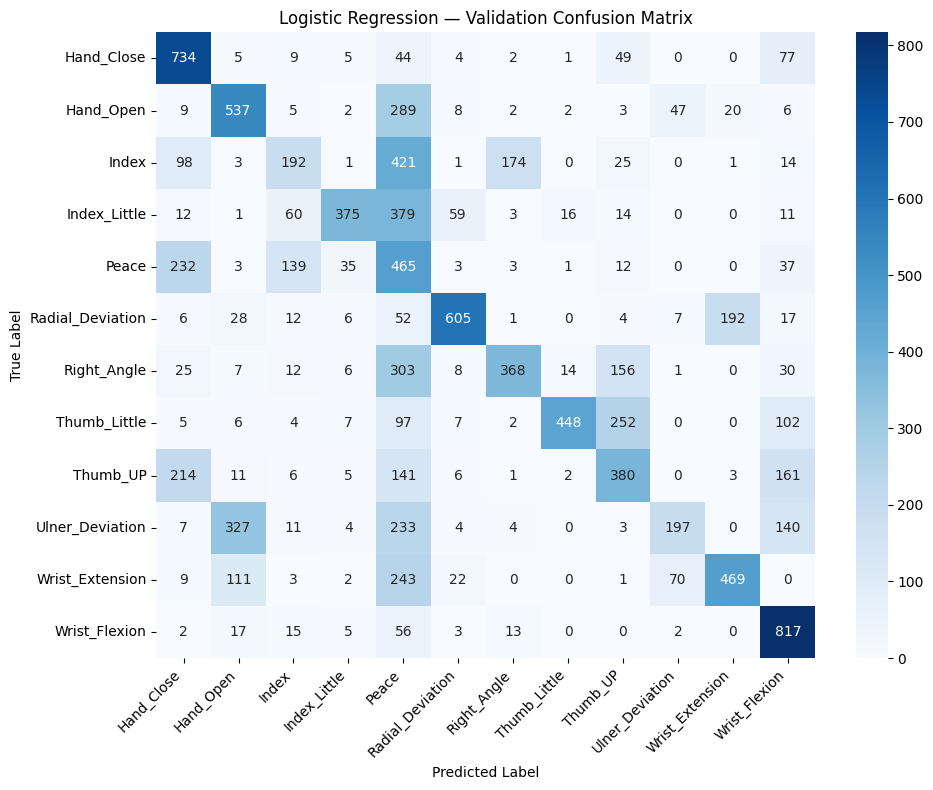

In [46]:
#confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = label_encoder.classes_


cm_lr = confusion_matrix(
    y_val_encoded,
    y_val_pred_lr
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [33]:
#Phase 11B — k-NN
#Cell 1 — Train k-NN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model.fit(
    X_train_scaled,
    y_train_encoded
)
#Cell 2 — Validation
y_val_pred_knn = knn_model.predict(X_val_scaled)

knn_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_knn
)

knn_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_knn,
    average="macro"
)
#results
print("k-NN")
print("Validation Accuracy:", round(knn_val_accuracy, 4))
print("Validation Macro F1 :", round(knn_val_f1, 4))
baseline_results.append({
    "Model": "k-NN",
    "Validation Accuracy": knn_val_accuracy,
    "Validation Macro F1": knn_val_f1
})

print(baseline_results)


k-NN
Validation Accuracy: 0.4254
Validation Macro F1 : 0.408
[{'Model': 'Logistic Regression', 'Validation Accuracy': 0.5006272401433691, 'Validation Macro F1': 0.5096541292845856}, {'Model': 'k-NN', 'Validation Accuracy': 0.4253584229390681, 'Validation Macro F1': 0.40796172290951455}]


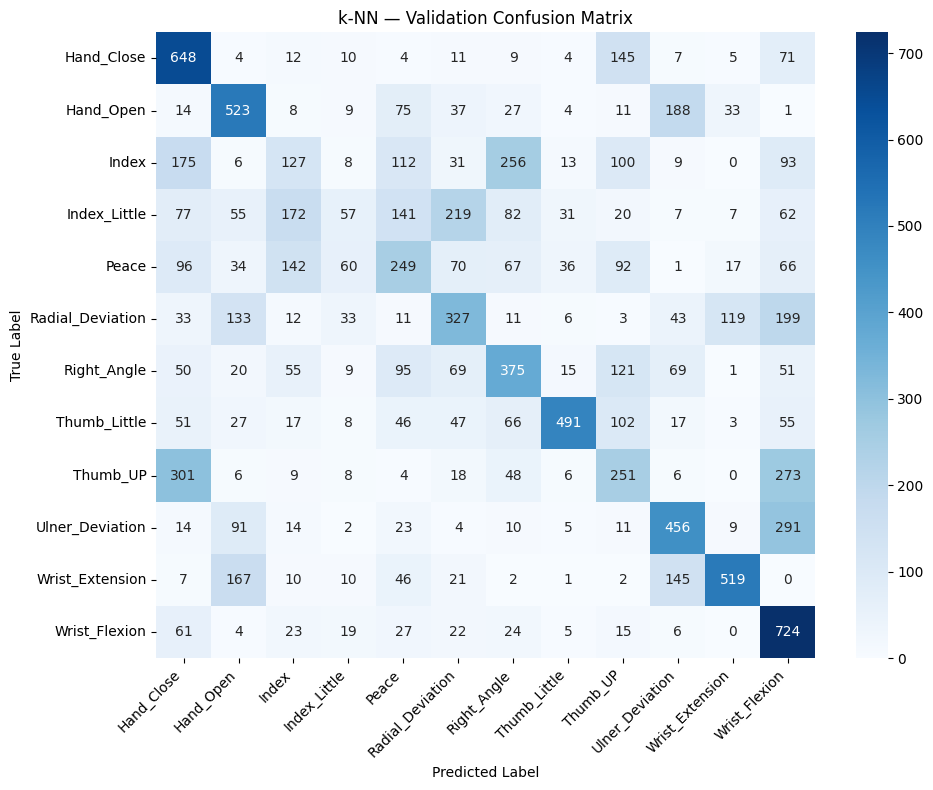

In [45]:
#k-NN
cm_knn = confusion_matrix(
    y_val_encoded,
    y_val_pred_knn
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("k-NN — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
#Phase 11C — Decision Tree
#Train
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train_scaled,
    y_train_encoded
)
#Validate
y_val_pred_dt = decision_tree_model.predict(X_val_scaled)

dt_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_dt
)

dt_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_dt,
    average="macro"
)
#results
print("Decision Tree")
print("Validation Accuracy:", round(dt_val_accuracy, 4))
print("Validation Macro F1 :", round(dt_val_f1, 4))
baseline_results.append({
    "Model": "Decision Tree",
    "Validation Accuracy": dt_val_accuracy,
    "Validation Macro F1": dt_val_f1
})

print(baseline_results)


Decision Tree
Validation Accuracy: 0.3532
Validation Macro F1 : 0.3492
[{'Model': 'Logistic Regression', 'Validation Accuracy': 0.5006272401433691, 'Validation Macro F1': 0.5096541292845856}, {'Model': 'k-NN', 'Validation Accuracy': 0.4253584229390681, 'Validation Macro F1': 0.40796172290951455}, {'Model': 'Decision Tree', 'Validation Accuracy': 0.3532258064516129, 'Validation Macro F1': 0.3491582910279059}]


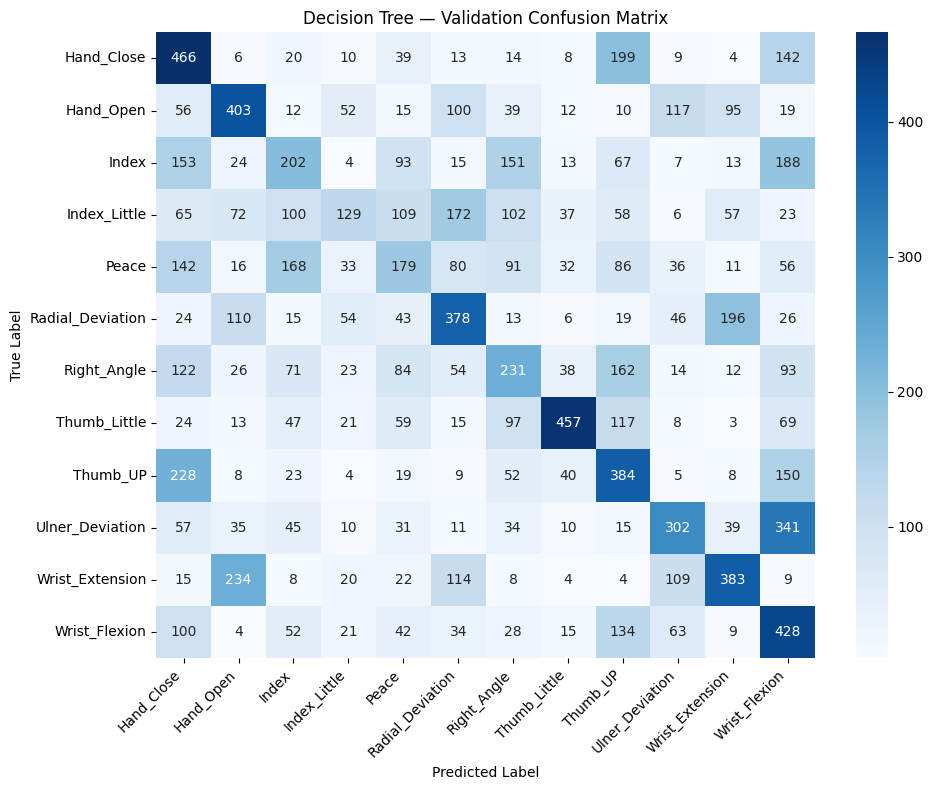

In [47]:
cm_dt = confusion_matrix(
    y_val_encoded,
    y_val_pred_dt
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [35]:
#Phase 11D — Random Forest
#Train
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_scaled,
    y_train_encoded
)
#validate
y_val_pred_rf = random_forest_model.predict(X_val_scaled)

rf_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_rf
)

rf_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_rf,
    average="macro"
)
#result
print("Random Forest")
print("Validation Accuracy:", round(rf_val_accuracy, 4))
print("Validation Macro F1 :", round(rf_val_f1, 4))

baseline_results.append({
    "Model": "Random Forest",
    "Validation Accuracy": rf_val_accuracy,
    "Validation Macro F1": rf_val_f1
})

print(baseline_results)

Random Forest
Validation Accuracy: 0.5145
Validation Macro F1 : 0.5011
[{'Model': 'Logistic Regression', 'Validation Accuracy': 0.5006272401433691, 'Validation Macro F1': 0.5096541292845856}, {'Model': 'k-NN', 'Validation Accuracy': 0.4253584229390681, 'Validation Macro F1': 0.40796172290951455}, {'Model': 'Decision Tree', 'Validation Accuracy': 0.3532258064516129, 'Validation Macro F1': 0.3491582910279059}, {'Model': 'Random Forest', 'Validation Accuracy': 0.5145161290322581, 'Validation Macro F1': 0.5011386536376005}]


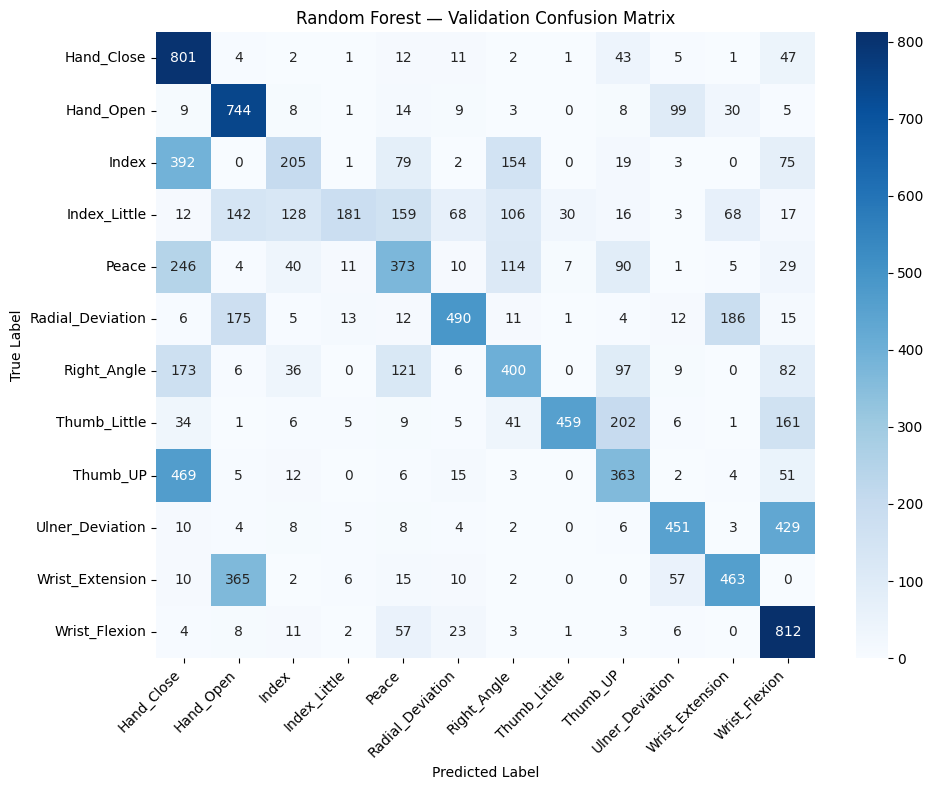

In [48]:
cm_rf = confusion_matrix(
    y_val_encoded,
    y_val_pred_rf
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
#Phase 11E — SVM
#Train
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000
)

svm_model.fit(
    X_train_scaled,
    y_train_encoded
)
#Validate
y_val_pred_svm = svm_model.predict(X_val_scaled)

svm_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_svm
)

svm_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_svm,
    average="macro"
)

print("SVM")
print("Validation Accuracy:", round(svm_val_accuracy, 4))
print("Validation Macro F1 :", round(svm_val_f1, 4))

baseline_results.append({
    "Model": "SVM",
    "Validation Accuracy": svm_val_accuracy,
    "Validation Macro F1": svm_val_f1
})

print(baseline_results)

SVM
Validation Accuracy: 0.4621
Validation Macro F1 : 0.4651
[{'Model': 'Logistic Regression', 'Validation Accuracy': 0.5006272401433691, 'Validation Macro F1': 0.5096541292845856}, {'Model': 'k-NN', 'Validation Accuracy': 0.4253584229390681, 'Validation Macro F1': 0.40796172290951455}, {'Model': 'Decision Tree', 'Validation Accuracy': 0.3532258064516129, 'Validation Macro F1': 0.3491582910279059}, {'Model': 'Random Forest', 'Validation Accuracy': 0.5145161290322581, 'Validation Macro F1': 0.5011386536376005}, {'Model': 'SVM', 'Validation Accuracy': 0.4620967741935484, 'Validation Macro F1': 0.465142334792306}]


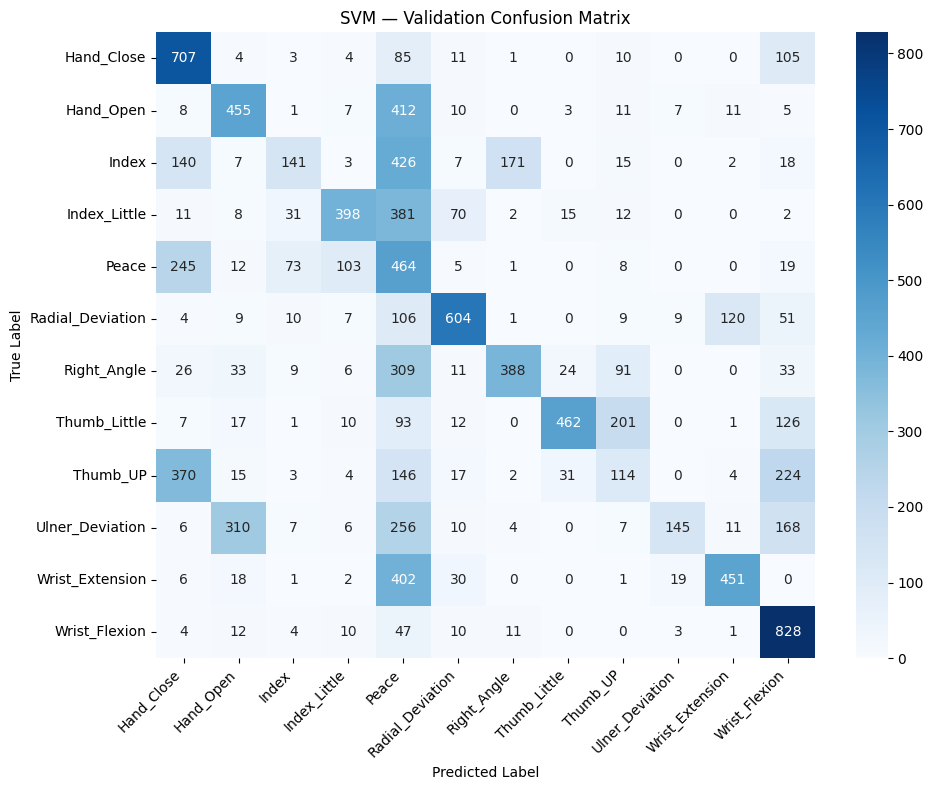

In [49]:
cm_svm = confusion_matrix(
    y_val_encoded,
    y_val_pred_svm
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
#Phase 11F — Gradient Boosting
#Train
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_scaled,
    y_train_encoded
)
#Validate
y_val_pred_gb = gradient_boosting_model.predict(X_val_scaled)

gb_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_gb
)

gb_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_gb,
    average="macro"
)

print("Gradient Boosting")
print("Validation Accuracy:", round(gb_val_accuracy, 4))
print("Validation Macro F1 :", round(gb_val_f1, 4))
baseline_results.append({
    "Model": "Gradient Boosting",
    "Validation Accuracy": gb_val_accuracy,
    "Validation Macro F1": gb_val_f1
})

print(baseline_results)

Gradient Boosting
Validation Accuracy: 0.4903
Validation Macro F1 : 0.4839
[{'Model': 'Logistic Regression', 'Validation Accuracy': 0.5006272401433691, 'Validation Macro F1': 0.5096541292845856}, {'Model': 'k-NN', 'Validation Accuracy': 0.4253584229390681, 'Validation Macro F1': 0.40796172290951455}, {'Model': 'Decision Tree', 'Validation Accuracy': 0.3532258064516129, 'Validation Macro F1': 0.3491582910279059}, {'Model': 'Random Forest', 'Validation Accuracy': 0.5145161290322581, 'Validation Macro F1': 0.5011386536376005}, {'Model': 'SVM', 'Validation Accuracy': 0.4620967741935484, 'Validation Macro F1': 0.465142334792306}, {'Model': 'Gradient Boosting', 'Validation Accuracy': 0.49032258064516127, 'Validation Macro F1': 0.48394215603200347}]


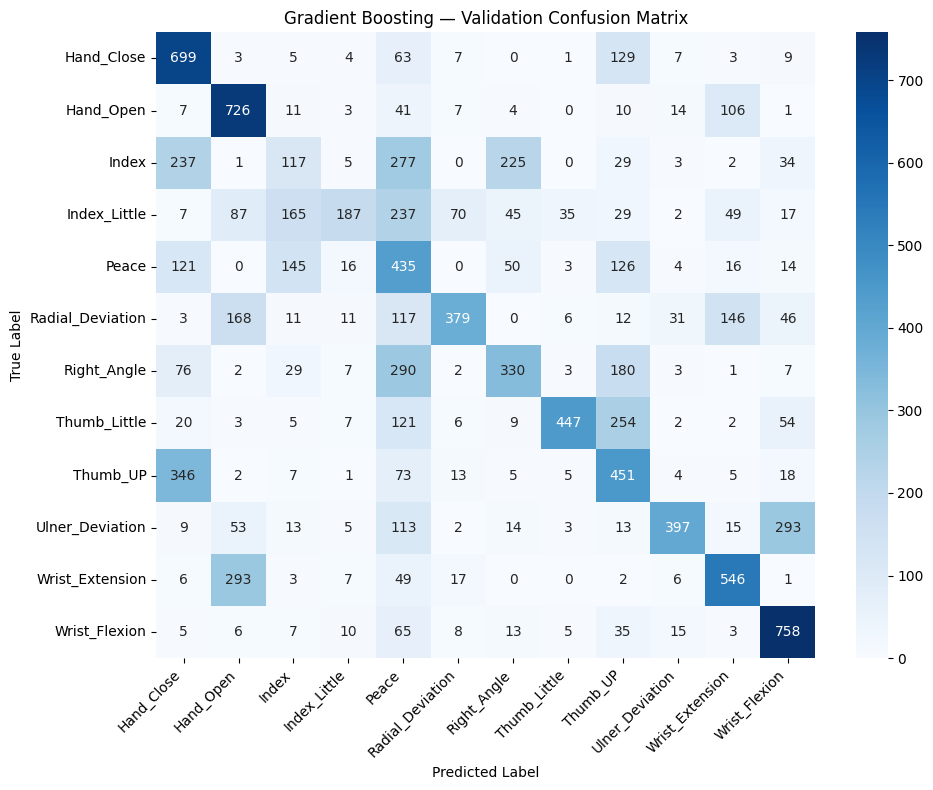

In [50]:
cm_gb = confusion_matrix(
    y_val_encoded,
    y_val_pred_gb
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Gradient Boosting — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

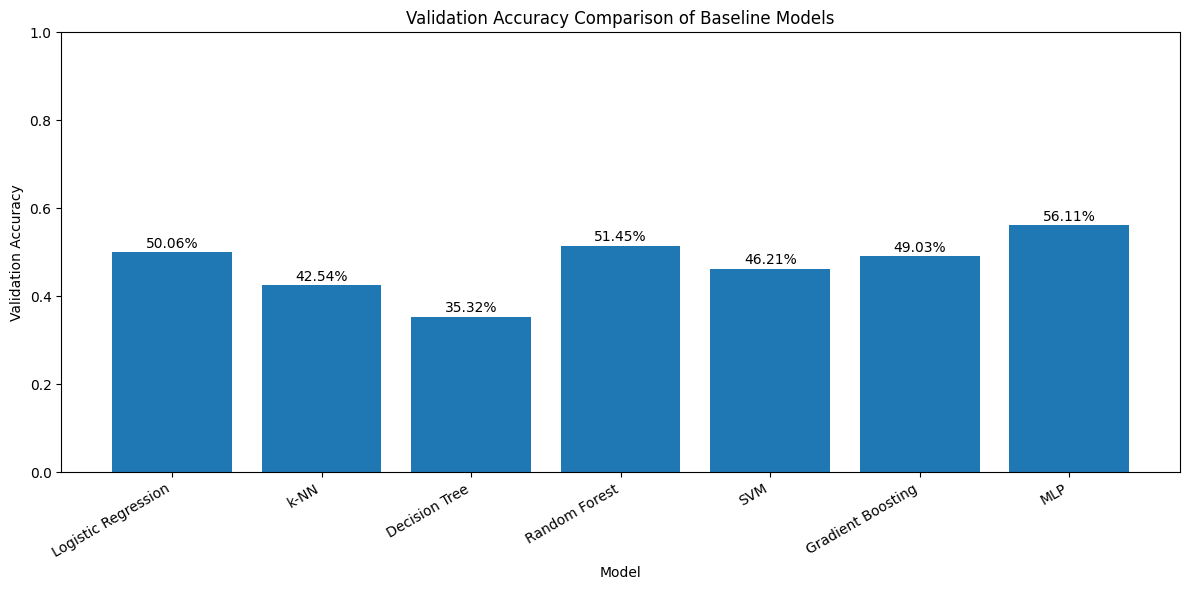

In [40]:
baseline_results.append({
    "Model": "MLP",
    "Validation Accuracy": 0.5611
})

import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "k-NN",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Gradient Boosting",
    "MLP"
]

accuracies = []

for model_name in models:
    if model_name == "MLP":
        accuracies.append(0.5611)
    else:
        result = next(
            item for item in baseline_results
            if item["Model"] == model_name
        )
        accuracies.append(result["Validation Accuracy"])

plt.figure(figsize=(12, 6))

bars = plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison of Baseline Models")

plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [54]:
#Phase 11G — XGBoost 
#train
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=12,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    random_state=42
)

xgb_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("XGBoost training completed.")

#Validate
y_val_pred_xgb = xgb_model.predict(X_val_scaled)

xgb_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_xgb
)

xgb_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_xgb,
    average="macro"
)

print("XGBoost")
print("Validation Accuracy:", round(xgb_val_accuracy, 4))
print("Validation Macro F1 :", round(xgb_val_f1, 4))
baseline_results.append({
    "Model": "XGBoost",
    "Validation Accuracy": xgb_val_accuracy,
    "Validation Macro F1": xgb_val_f1
})

print(baseline_results)


XGBoost training completed.
XGBoost
Validation Accuracy: 0.5119
Validation Macro F1 : 0.5132
[{'Model': 'Logistic Regression', 'Validation Accuracy': 0.5006272401433691, 'Validation Macro F1': 0.5096541292845856}, {'Model': 'k-NN', 'Validation Accuracy': 0.4253584229390681, 'Validation Macro F1': 0.40796172290951455}, {'Model': 'Decision Tree', 'Validation Accuracy': 0.3532258064516129, 'Validation Macro F1': 0.3491582910279059}, {'Model': 'Random Forest', 'Validation Accuracy': 0.5145161290322581, 'Validation Macro F1': 0.5011386536376005}, {'Model': 'SVM', 'Validation Accuracy': 0.4620967741935484, 'Validation Macro F1': 0.465142334792306}, {'Model': 'Gradient Boosting', 'Validation Accuracy': 0.49032258064516127, 'Validation Macro F1': 0.48394215603200347}, {'Model': 'MLP', 'Validation Accuracy': 0.5611}, {'Model': 'MLP', 'Validation Accuracy': 0.5611}, {'Model': 'MLP', 'Validation Accuracy': 0.5611}, {'Model': 'XGBoost', 'Validation Accuracy': 0.5119175627240143, 'Validation Macro 

C:\Users\Asus\miniconda3\envs\research_env\Lib\site-packages\xgboost\core.py:751: UserWarning: [16:50:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


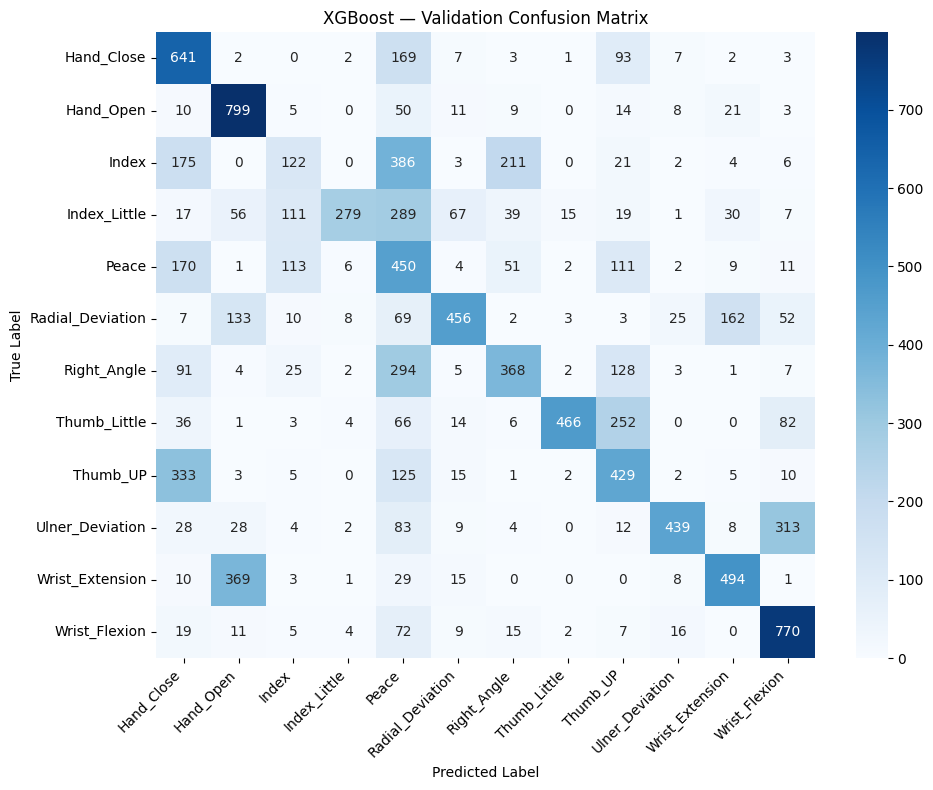

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(
    y_val_encoded,
    y_val_pred_xgb
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [59]:
#Phase 11H — LightGBM
from lightgbm import LGBMClassifier

lightgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multiclass",
    num_class=12,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lightgbm_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("LightGBM training completed.")

LightGBM training completed.


In [60]:
y_val_pred_lgbm = lightgbm_model.predict(X_val_scaled)

lgbm_val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_lgbm
)

lgbm_val_f1 = f1_score(
    y_val_encoded,
    y_val_pred_lgbm,
    average="macro"
)

print("LightGBM")
print("Validation Accuracy:", round(lgbm_val_accuracy, 4))
print("Validation Macro F1 :", round(lgbm_val_f1, 4))

LightGBM
Validation Accuracy: 0.5193
Validation Macro F1 : 0.5207


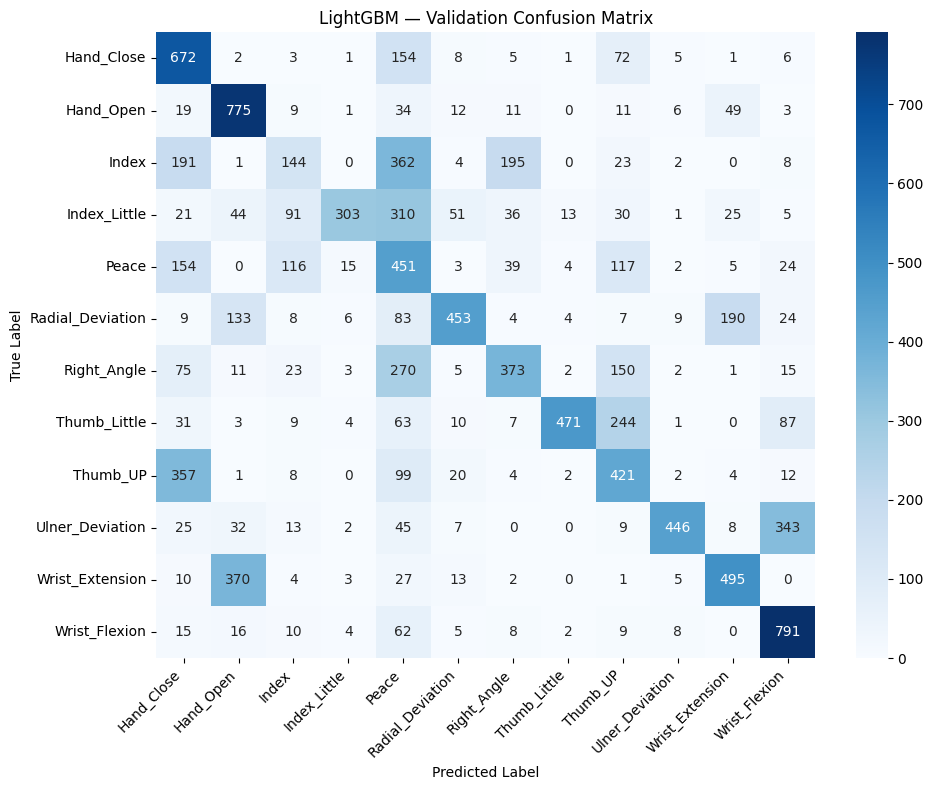

In [61]:
cm_lgbm = confusion_matrix(
    y_val_encoded,
    y_val_pred_lgbm
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LightGBM — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "lightgbm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
#Phase 11I — 1D-CNN Baseline
import numpy as np
import scipy.io as sio
import torch
from torch.utils.data import TensorDataset, DataLoader

def process_cnn_split(metadata):
    all_windows = []
    all_labels = []

    for _, row in metadata.iterrows():
        data = sio.loadmat(row["File"])
        signal = data["value"]

        windows = make_windows(signal)

        for window in windows:
            all_windows.append(window)
            all_labels.append(row["Gesture"])

    X = np.array(all_windows, dtype=np.float32)
    y = np.array(all_labels)

    return X, y

In [63]:
X_train_cnn, y_train_cnn = process_cnn_split(train_metadata)

X_val_cnn, y_val_cnn = process_cnn_split(val_metadata)

X_test_cnn, y_test_cnn = process_cnn_split(test_metadata)

print("Training shape:", X_train_cnn.shape)
print("Validation shape:", X_val_cnn.shape)
print("Test shape:", X_test_cnn.shape)

Training shape: (83700, 8, 492)
Validation shape: (11160, 8, 492)
Test shape: (11160, 8, 492)


In [64]:
from sklearn.preprocessing import LabelEncoder

label_encoder_cnn = LabelEncoder()

y_train_cnn_encoded = label_encoder_cnn.fit_transform(y_train_cnn)

y_val_cnn_encoded = label_encoder_cnn.transform(y_val_cnn)

y_test_cnn_encoded = label_encoder_cnn.transform(y_test_cnn)

class_names_cnn = label_encoder_cnn.classes_

print("Classes:", class_names_cnn)
print("Number of classes:", len(class_names_cnn))

Classes: ['Hand_Close' 'Hand_Open' 'Index' 'Index_Little' 'Peace'
 'Radial_Deviation' 'Right_Angle' 'Thumb_Little' 'Thumb_UP'
 'Ulner_Deviation' 'Wrist_Extension' 'Wrist_Flexion']
Number of classes: 12


In [67]:
channel_mean = X_train_cnn.mean(axis=(0, 2), keepdims=True)

channel_std = X_train_cnn.std(axis=(0, 2), keepdims=True)

channel_std[channel_std == 0] = 1.0
X_train_cnn = (
    X_train_cnn - channel_mean
) / channel_std

X_val_cnn = (
    X_val_cnn - channel_mean
) / channel_std

X_test_cnn = (
    X_test_cnn - channel_mean
) / channel_std
print("Training mean:", X_train_cnn.mean())
print("Training std :", X_train_cnn.std())

print("Training shape:", X_train_cnn.shape)
print("Validation shape:", X_val_cnn.shape)
print("Test shape:", X_test_cnn.shape)

Training mean: -5.2527074e-08
Training std : 0.9999993
Training shape: (83700, 8, 492)
Validation shape: (11160, 8, 492)
Test shape: (11160, 8, 492)


In [68]:
X_train_cnn = torch.tensor(
    X_train_cnn,
    dtype=torch.float32
)

X_val_cnn = torch.tensor(
    X_val_cnn,
    dtype=torch.float32
)

X_test_cnn = torch.tensor(
    X_test_cnn,
    dtype=torch.float32
)

y_train_cnn_encoded = torch.tensor(
    y_train_cnn_encoded,
    dtype=torch.long
)

y_val_cnn_encoded = torch.tensor(
    y_val_cnn_encoded,
    dtype=torch.long
)

y_test_cnn_encoded = torch.tensor(
    y_test_cnn_encoded,
    dtype=torch.long
)

In [69]:
BATCH_SIZE = 256

train_cnn_dataset = TensorDataset(
    X_train_cnn,
    y_train_cnn_encoded
)

val_cnn_dataset = TensorDataset(
    X_val_cnn,
    y_val_cnn_encoded
)

test_cnn_dataset = TensorDataset(
    X_test_cnn,
    y_test_cnn_encoded
)

train_cnn_loader = DataLoader(
    train_cnn_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_cnn_loader = DataLoader(
    val_cnn_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_cnn_loader = DataLoader(
    test_cnn_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_cnn_loader))
print("Validation batches:", len(val_cnn_loader))
print("Test batches:", len(test_cnn_loader))

Training batches: 327
Validation batches: 44
Test batches: 44


In [70]:
import torch.nn as nn

class CNN1D(nn.Module):

    def __init__(self, num_classes=12):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=8,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            ),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            ),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        x = x.squeeze(-1)

        x = self.classifier(x)

        return x

In [71]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

cnn_model = CNN1D(
    num_classes=12
).to(device)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

print(cnn_model)

Device: cuda
GPU: NVIDIA GeForce RTX 3060
CNN1D(
  (features): Sequential(
    (0): Conv1d(8, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Linear(in_features=128, out_features=12, bias=True)
)


In [72]:
sample_batch, sample_labels = next(
    iter(train_cnn_loader)
)

sample_batch = sample_batch.to(device)

output = cnn_model(sample_batch)

print("Input shape :", sample_batch.shape)
print("Output shape:", output.shape)


Input shape : torch.Size([256, 8, 492])
Output shape: torch.Size([256, 12])


In [73]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

EPOCHS = 30

In [74]:
for epoch in range(EPOCHS):

    cnn_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_cnn_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = cnn_model(inputs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss /= train_total

    train_accuracy = (
        train_correct / train_total
    )

    cnn_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_cnn_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = cnn_model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item() * inputs.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= val_total

    val_accuracy = (
        val_correct / val_total
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01/30 | Train Loss: 1.6395 | Train Acc: 0.4183 | Val Loss: 1.7216 | Val Acc: 0.4663
Epoch 02/30 | Train Loss: 1.1745 | Train Acc: 0.5855 | Val Loss: 2.1522 | Val Acc: 0.4937
Epoch 03/30 | Train Loss: 1.0236 | Train Acc: 0.6423 | Val Loss: 2.0077 | Val Acc: 0.5044
Epoch 04/30 | Train Loss: 0.9435 | Train Acc: 0.6725 | Val Loss: 2.1458 | Val Acc: 0.5316
Epoch 05/30 | Train Loss: 0.8831 | Train Acc: 0.6970 | Val Loss: 2.3760 | Val Acc: 0.5011
Epoch 06/30 | Train Loss: 0.8381 | Train Acc: 0.7119 | Val Loss: 2.0850 | Val Acc: 0.5426
Epoch 07/30 | Train Loss: 0.8015 | Train Acc: 0.7248 | Val Loss: 2.7591 | Val Acc: 0.4913
Epoch 08/30 | Train Loss: 0.7634 | Train Acc: 0.7396 | Val Loss: 2.5454 | Val Acc: 0.5259
Epoch 09/30 | Train Loss: 0.7397 | Train Acc: 0.7483 | Val Loss: 2.9493 | Val Acc: 0.4712
Epoch 10/30 | Train Loss: 0.7141 | Train Acc: 0.7555 | Val Loss: 2.7724 | Val Acc: 0.4957
Epoch 11/30 | Train Loss: 0.6978 | Train Acc: 0.7622 | Val Loss: 2.8924 | Val Acc: 0.4914
Epoch 12/3

In [75]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

cnn_model.eval()

all_cnn_predictions = []
all_cnn_labels = []

with torch.no_grad():

    for inputs, labels in val_cnn_loader:

        inputs = inputs.to(device)

        outputs = cnn_model(inputs)

        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_cnn_predictions.extend(predictions)
        all_cnn_labels.extend(labels.numpy())

all_cnn_predictions = np.array(all_cnn_predictions)
all_cnn_labels = np.array(all_cnn_labels)

In [76]:
cnn_val_accuracy = accuracy_score(
    all_cnn_labels,
    all_cnn_predictions
)

cnn_val_f1 = f1_score(
    all_cnn_labels,
    all_cnn_predictions,
    average="macro"
)

print("1D-CNN")
print("Validation Accuracy:", round(cnn_val_accuracy, 4))
print("Validation Macro F1 :", round(cnn_val_f1, 4))

1D-CNN
Validation Accuracy: 0.5241
Validation Macro F1 : 0.5138


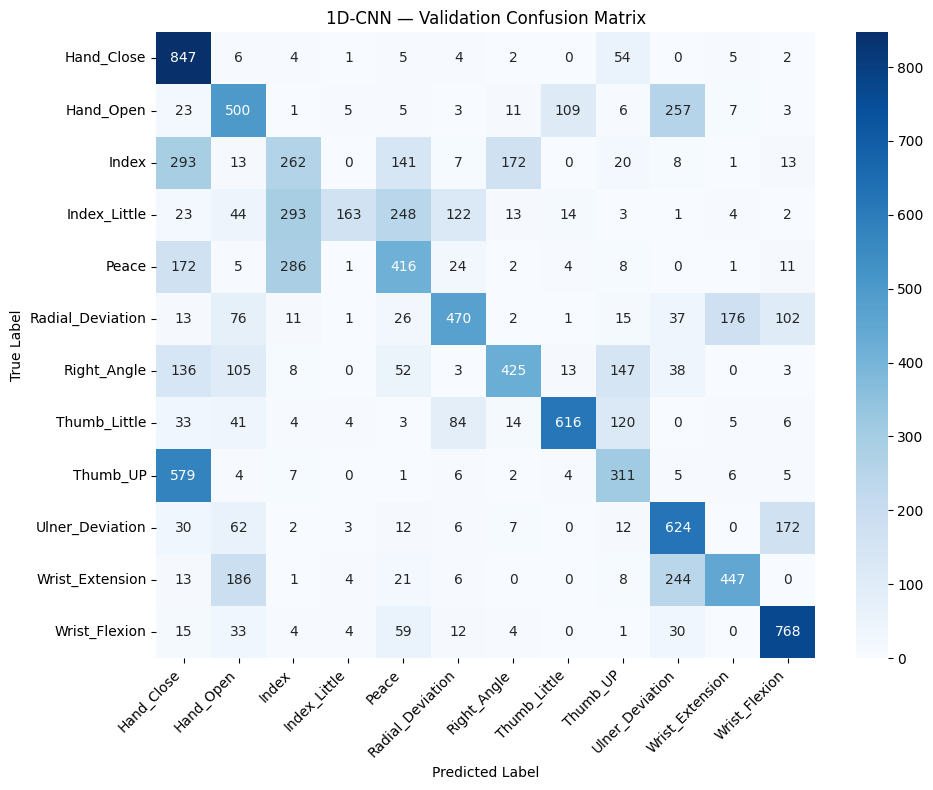

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_cnn = confusion_matrix(
    all_cnn_labels,
    all_cnn_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_cnn,
    yticklabels=class_names_cnn
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("1D-CNN — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "cnn_1d_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
#Phase11J-MLP
import torch
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, input_size=104, num_classes=12):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [79]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

mlp_model = MLP(
    input_size=104,
    num_classes=12
).to(device)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print(mlp_model)

Device: cuda
GPU: NVIDIA GeForce RTX 3060
MLP(
  (network): Sequential(
    (0): Linear(in_features=104, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=12, bias=True)
  )
)


In [80]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

EPOCHS = 30

best_val_accuracy = 0.0
best_epoch = 0
best_model_state = None

In [81]:
for epoch in range(EPOCHS):

    mlp_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = mlp_model(inputs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss /= train_total

    train_accuracy = (
        train_correct / train_total
    )

    mlp_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = mlp_model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item() * inputs.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= val_total

    val_accuracy = (
        val_correct / val_total
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        best_model_state = {
            key: value.cpu().clone()
            for key, value in mlp_model.state_dict().items()
        }

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01/30 | Train Loss: 1.1307 | Train Acc: 0.6209 | Val Loss: 1.9988 | Val Acc: 0.5247
Epoch 02/30 | Train Loss: 0.6460 | Train Acc: 0.7863 | Val Loss: 2.4165 | Val Acc: 0.5239
Epoch 03/30 | Train Loss: 0.5250 | Train Acc: 0.8293 | Val Loss: 2.5001 | Val Acc: 0.5502
Epoch 04/30 | Train Loss: 0.4561 | Train Acc: 0.8545 | Val Loss: 2.8398 | Val Acc: 0.5309
Epoch 05/30 | Train Loss: 0.4130 | Train Acc: 0.8677 | Val Loss: 2.7752 | Val Acc: 0.5453
Epoch 06/30 | Train Loss: 0.3841 | Train Acc: 0.8773 | Val Loss: 2.9429 | Val Acc: 0.5466
Epoch 07/30 | Train Loss: 0.3621 | Train Acc: 0.8845 | Val Loss: 3.1620 | Val Acc: 0.5353
Epoch 08/30 | Train Loss: 0.3424 | Train Acc: 0.8905 | Val Loss: 3.2469 | Val Acc: 0.5334
Epoch 09/30 | Train Loss: 0.3276 | Train Acc: 0.8947 | Val Loss: 3.3244 | Val Acc: 0.5431
Epoch 10/30 | Train Loss: 0.3168 | Train Acc: 0.8980 | Val Loss: 3.4033 | Val Acc: 0.5481
Epoch 11/30 | Train Loss: 0.3044 | Train Acc: 0.9015 | Val Loss: 3.7045 | Val Acc: 0.5368
Epoch 12/3

In [85]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np

mlp_model.load_state_dict(best_model_state)
mlp_model = mlp_model.to(device)
mlp_model.eval()

all_mlp_predictions = []
all_mlp_labels = []

with torch.no_grad():

    for inputs, labels in val_loader:

        inputs = inputs.to(device)

        outputs = mlp_model(inputs)

        predictions = outputs.argmax(dim=1)

        all_mlp_predictions.extend(
            predictions.cpu().numpy()
        )

        all_mlp_labels.extend(
            labels.numpy()
        )

all_mlp_predictions = np.array(all_mlp_predictions)
all_mlp_labels = np.array(all_mlp_labels)

mlp_val_accuracy = accuracy_score(
    all_mlp_labels,
    all_mlp_predictions
)

mlp_val_f1 = f1_score(
    all_mlp_labels,
    all_mlp_predictions,
    average="macro"
)

print("MLP")
print("Validation Accuracy:", round(mlp_val_accuracy, 4))
print("Validation Macro F1 :", round(mlp_val_f1, 4))
print("Best Epoch:", best_epoch)

MLP
Validation Accuracy: 0.5502
Validation Macro F1 : 0.5457
Best Epoch: 3


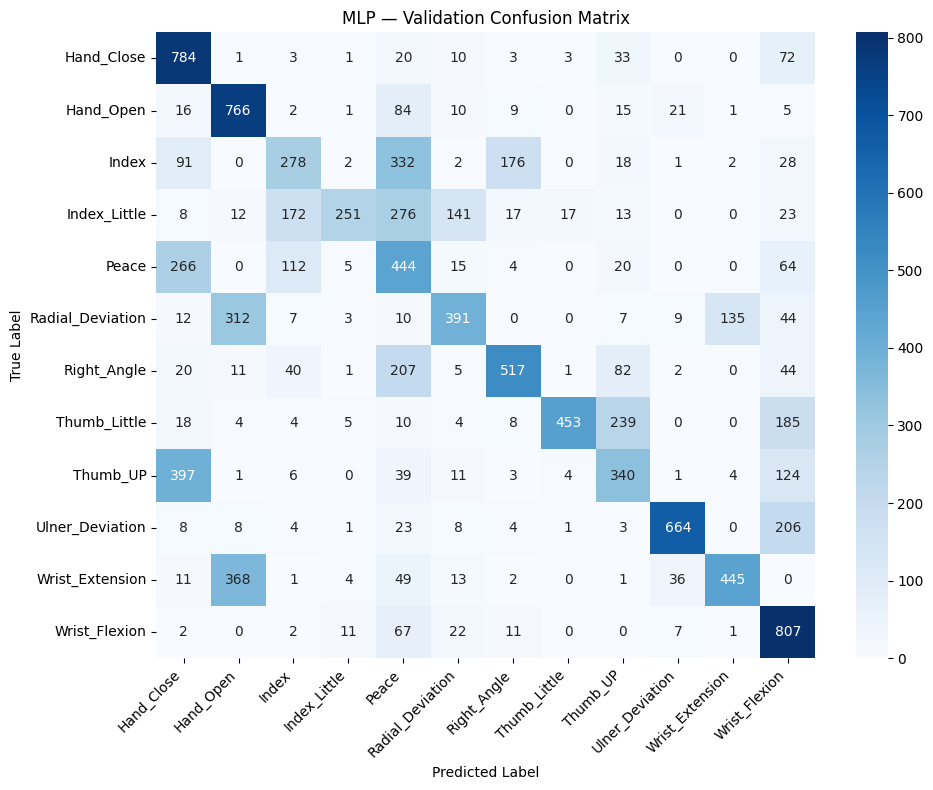

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_mlp = confusion_matrix(
    all_mlp_labels,
    all_mlp_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MLP — Validation Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "mlp_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [97]:
#Phase 12.1 — First check our existing variables
print("Checking existing models...")
print()

print("Logistic Regression:", "logistic_model" in globals())
print("k-NN:", "knn_model" in globals())
print("Decision Tree:", "decision_tree_model" in globals())
print("Random Forest:", "random_forest_model" in globals())
print("SVM:", "svm_model" in globals())
print("Gradient Boosting:", "gradient_boosting_model" in globals())
print("XGBoost:", "xgb_model" in globals())
print("LightGBM:", "lgb_model" in globals())

print()

print("PyTorch models:")
print("MLP:", "mlp_model" in globals())
print("CNN:", "cnn_model" in globals())

Checking existing models...

Logistic Regression: True
k-NN: True
Decision Tree: True
Random Forest: True
SVM: True
Gradient Boosting: True
XGBoost: True
LightGBM: False

PyTorch models:
MLP: True
CNN: True


In [99]:
#Phase 12.2 — Find LightGBM model
print("LightGBM-related variables:")
print()

for name in list(globals().keys()):
    try:
        value = globals()[name]
        module_name = value.__class__.__module__.lower()
        class_name = value.__class__.__name__.lower()

        if "lightgbm" in module_name or "lgbm" in class_name:
            print(name, "->", value.__class__.__name__)
    except:
        pass

LightGBM-related variables:

lightgbm_model -> LGBMClassifier


In [105]:
print()
print("Available feature-related variables:")

for name in list(globals().keys()):
    if "train" in name.lower() or "val" in name.lower():
        if "feature" in name.lower() or name.startswith("X_"):
            print(name)


Available feature-related variables:
X_train
X_val
X_train_scaled
X_val_scaled
X_train_tensor
X_val_tensor
X_train_cnn
X_val_cnn


In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }

print("Using X_val_scaled:", X_val_scaled.shape)

Using X_val_scaled: (11160, 104)


In [107]:
#evaluate the 8 traditional models
baseline_results = []

models = {
    "Logistic Regression": logistic_model,
    "k-NN": knn_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "SVM": svm_model,
    "Gradient Boosting": gradient_boosting_model,
    "XGBoost": xgb_model,
    "LightGBM": lightgbm_model
}

for name, model in models.items():

    predictions = model.predict(X_val_scaled)

    metrics = calculate_metrics(
        y_val_encoded,
        predictions
    )

    metrics["Model"] = name

    baseline_results.append(metrics)

    print("=" * 60)
    print(name)
    print("=" * 60)
    print("Accuracy        :", round(metrics["Accuracy"], 4))
    print("Macro Precision :", round(metrics["Macro Precision"], 4))
    print("Macro Recall    :", round(metrics["Macro Recall"], 4))
    print("Macro F1        :", round(metrics["Macro F1"], 4))
    print("Weighted F1     :", round(metrics["Weighted F1"], 4))

Logistic Regression
Accuracy        : 0.5006
Macro Precision : 0.5959
Macro Recall    : 0.5006
Macro F1        : 0.5097
Weighted F1     : 0.5097
k-NN
Accuracy        : 0.4254
Macro Precision : 0.4249
Macro Recall    : 0.4254
Macro F1        : 0.408
Weighted F1     : 0.408
Decision Tree
Accuracy        : 0.3532
Macro Precision : 0.3653
Macro Recall    : 0.3532
Macro F1        : 0.3492
Weighted F1     : 0.3492
Random Forest
Accuracy        : 0.5145
Macro Precision : 0.5747
Macro Recall    : 0.5145
Macro F1        : 0.5011
Weighted F1     : 0.5011
SVM
Accuracy        : 0.4621
Macro Precision : 0.5764
Macro Recall    : 0.4621
Macro F1        : 0.4651
Weighted F1     : 0.4651
Gradient Boosting
Accuracy        : 0.4903
Macro Precision : 0.5537
Macro Recall    : 0.4903
Macro F1        : 0.4839
Weighted F1     : 0.4839
XGBoost
Accuracy        : 0.5119
Macro Precision : 0.5952
Macro Recall    : 0.5119
Macro F1        : 0.5132
Weighted F1     : 0.5132
LightGBM
Accuracy        : 0.5193
Macro Prec

In [108]:
#Phase 12.4 — Full evaluation of MLP
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mlp_model.eval()

mlp_predictions = []
mlp_true = []

with torch.no_grad():

    for inputs, labels in val_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = mlp_model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        mlp_predictions.extend(
            predictions.cpu().numpy()
        )

        mlp_true.extend(
            labels.cpu().numpy()
        )

mlp_metrics = {
    "Model": "MLP",
    "Accuracy": accuracy_score(mlp_true, mlp_predictions),
    "Macro Precision": precision_score(
        mlp_true,
        mlp_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        mlp_true,
        mlp_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        mlp_true,
        mlp_predictions,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        mlp_true,
        mlp_predictions,
        average="weighted",
        zero_division=0
    )
}

print("=" * 60)
print("MLP - FULL VALIDATION EVALUATION")
print("=" * 60)

print("Accuracy        :", round(mlp_metrics["Accuracy"], 4))
print("Macro Precision :", round(mlp_metrics["Macro Precision"], 4))
print("Macro Recall    :", round(mlp_metrics["Macro Recall"], 4))
print("Macro F1        :", round(mlp_metrics["Macro F1"], 4))
print("Weighted F1     :", round(mlp_metrics["Weighted F1"], 4))

MLP - FULL VALIDATION EVALUATION
Accuracy        : 0.5502
Macro Precision : 0.6208
Macro Recall    : 0.5502
Macro F1        : 0.5457
Weighted F1     : 0.5457


In [110]:
print("CNN-related variables:")

for name in list(globals().keys()):
    if "cnn" in name.lower():
        print(name)

CNN-related variables:
process_cnn_split
X_train_cnn
y_train_cnn
X_val_cnn
y_val_cnn
X_test_cnn
y_test_cnn
label_encoder_cnn
y_train_cnn_encoded
y_val_cnn_encoded
y_test_cnn_encoded
class_names_cnn
train_cnn_dataset
val_cnn_dataset
test_cnn_dataset
train_cnn_loader
val_cnn_loader
test_cnn_loader
CNN1D
cnn_model
all_cnn_predictions
all_cnn_labels
cnn_val_accuracy
cnn_val_f1
cm_cnn
cnn_predictions
cnn_true


In [111]:
#Phase 12.5 — Evaluate 1D-CNN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cnn_model.eval()

cnn_predictions = []
cnn_true = []

with torch.no_grad():

    for inputs, labels in val_cnn_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = cnn_model(inputs)

        predictions = torch.argmax(outputs, dim=1)

        cnn_predictions.extend(
            predictions.cpu().numpy()
        )

        cnn_true.extend(
            labels.cpu().numpy()
        )

cnn_metrics = {
    "Model": "1D-CNN",
    "Accuracy": accuracy_score(
        cnn_true,
        cnn_predictions
    ),
    "Macro Precision": precision_score(
        cnn_true,
        cnn_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        cnn_true,
        cnn_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        cnn_true,
        cnn_predictions,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        cnn_true,
        cnn_predictions,
        average="weighted",
        zero_division=0
    )
}

print("=" * 60)
print("1D-CNN - FULL VALIDATION EVALUATION")
print("=" * 60)

print("Accuracy        :", round(cnn_metrics["Accuracy"], 4))
print("Macro Precision :", round(cnn_metrics["Macro Precision"], 4))
print("Macro Recall    :", round(cnn_metrics["Macro Recall"], 4))
print("Macro F1        :", round(cnn_metrics["Macro F1"], 4))
print("Weighted F1     :", round(cnn_metrics["Weighted F1"], 4))

1D-CNN - FULL VALIDATION EVALUATION
Accuracy        : 0.5241
Macro Precision : 0.5726
Macro Recall    : 0.5241
Macro F1        : 0.5138
Weighted F1     : 0.5138


In [112]:
#Phase 12.6 — Final Baseline Comparison
import pandas as pd

final_results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.5006,
        "Macro Precision": 0.5959,
        "Macro Recall": 0.5006,
        "Macro F1": 0.5097,
        "Weighted F1": 0.5097
    },
    {
        "Model": "k-NN",
        "Accuracy": 0.4254,
        "Macro Precision": 0.4249,
        "Macro Recall": 0.4254,
        "Macro F1": 0.4080,
        "Weighted F1": 0.4080
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.3532,
        "Macro Precision": 0.3653,
        "Macro Recall": 0.3532,
        "Macro F1": 0.3492,
        "Weighted F1": 0.3492
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.5145,
        "Macro Precision": 0.5747,
        "Macro Recall": 0.5145,
        "Macro F1": 0.5011,
        "Weighted F1": 0.5011
    },
    {
        "Model": "SVM",
        "Accuracy": 0.4621,
        "Macro Precision": 0.5764,
        "Macro Recall": 0.4621,
        "Macro F1": 0.4651,
        "Weighted F1": 0.4651
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": 0.4903,
        "Macro Precision": 0.5537,
        "Macro Recall": 0.4903,
        "Macro F1": 0.4839,
        "Weighted F1": 0.4839
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.5119,
        "Macro Precision": 0.5952,
        "Macro Recall": 0.5119,
        "Macro F1": 0.5132,
        "Weighted F1": 0.5132
    },
    {
        "Model": "LightGBM",
        "Accuracy": 0.5193,
        "Macro Precision": 0.6015,
        "Macro Recall": 0.5193,
        "Macro F1": 0.5207,
        "Weighted F1": 0.5207
    },
    {
        "Model": "1D-CNN",
        "Accuracy": 0.5241,
        "Macro Precision": 0.5726,
        "Macro Recall": 0.5241,
        "Macro F1": 0.5138,
        "Weighted F1": 0.5138
    },
    {
        "Model": "MLP",
        "Accuracy": 0.5502,
        "Macro Precision": 0.6208,
        "Macro Recall": 0.5502,
        "Macro F1": 0.5457,
        "Weighted F1": 0.5457
    }
]

final_comparison = pd.DataFrame(final_results)

final_comparison = final_comparison.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

print("=" * 100)
print("PHASE 12 — FINAL BASELINE COMPARISON")
print("=" * 100)

print(
    final_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

PHASE 12 — FINAL BASELINE COMPARISON
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1
                MLP    0.5502           0.6208        0.5502    0.5457       0.5457
           LightGBM    0.5193           0.6015        0.5193    0.5207       0.5207
             1D-CNN    0.5241           0.5726        0.5241    0.5138       0.5138
            XGBoost    0.5119           0.5952        0.5119    0.5132       0.5132
Logistic Regression    0.5006           0.5959        0.5006    0.5097       0.5097
      Random Forest    0.5145           0.5747        0.5145    0.5011       0.5011
  Gradient Boosting    0.4903           0.5537        0.4903    0.4839       0.4839
                SVM    0.4621           0.5764        0.4621    0.4651       0.4651
               k-NN    0.4254           0.4249        0.4254    0.4080       0.4080
      Decision Tree    0.3532           0.3653        0.3532    0.3492       0.3492
